### Implementation of insertion sort

In [48]:
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key
    return arr

### Implementation of selection sort

In [49]:
def selection_sort(arr):
    n=len(arr)
    for i in range (n-1):
        minNum=arr[i]
        minindex=i
        for j in range (i+1,n):
            if arr[j]<minNum:
                minindex=j
                minNum =arr[j]
        arr[i], arr[minindex] = arr[minindex], arr[i]
    return arr

### Implementation of Bubble sort (with optimization)

In [50]:
def bubble_sort_optimized(arr):
    n = len(arr)
    for i in range(n) : 
        is_already_sorted = True
        for j in range(n-i-1):
            if(arr[j]>arr[j+1]):
                arr[j],arr[j+1] = arr[j+1],arr[j]
                is_already_sorted = False
        if (is_already_sorted  == True ):
            break
    return arr 

### Implementation of bubble sort (with no optimization)

In [51]:
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        for j in range(n-1-i):
            if(arr[j]>arr[j+1]):
                arr[j],arr[j+1] = arr[j+1],arr[j]
    return arr

## Testing the previous code maually

In [52]:
arr1 = [1,2,3,4,5,6,7] # sorted array 
arr2 = [4,3,5,6,1,2,7] # random array
arr3 = [7,6,5,4,3,2,1] # reverse sorted
arr = [arr1,arr2,arr3]
for x in arr :
    print(bubble_sort(x.copy()))
    print(bubble_sort_optimized(x.copy()))
    print(selection_sort(x.copy()))
    print(insertion_sort(x.copy()))
    print("-"*20)

[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
--------------------
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
--------------------
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
[1, 2, 3, 4, 5, 6, 7]
--------------------


### Making comparison between optimized and non optimized bubble sort

In [53]:
import time 
import random
import matplotlib.pyplot as plt

# Generating random and sorted array
arr_random = [random.randint(1, 10000) for _ in range(10000)]
arr_sorted = list(range(0,10000))


# making copies because values are changed by reference
random_arr1 = arr_random.copy()
random_arr2 = arr_random.copy()
# calculating the time of non optimized bubble sort on random array
start = time.perf_counter()
bubble_sort(random_arr1)
end = time.perf_counter()
time_non_opt_random = end - start
# calculating the time of optimized bubble sort on random array
start = time.perf_counter()
bubble_sort_optimized(random_arr2)
end = time.perf_counter()
time_opt_random = end - start

#making copies because values are changed by reference
sorted_arr1 = arr_sorted.copy()
sorted_arr2 = arr_sorted.copy()
# calculating the time of non optimized bubble sort on sorted array
start = time.perf_counter()
bubble_sort(sorted_arr1)
end = time.perf_counter()
time_non_opt_sorted = end - start
# calculating the time of optimized bubble sort on sorted array
start = time.perf_counter()
bubble_sort_optimized(sorted_arr2)
end = time.perf_counter()
time_opt_sorted = end - start

## visualizing the comparison 

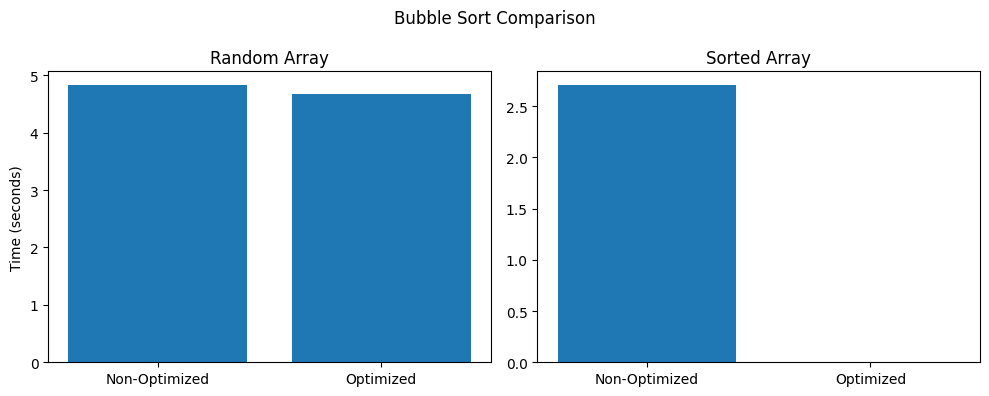

In [54]:
# definig a figure of 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# first subplot
axes[0].bar(
    ["Non-Optimized", "Optimized"],
    [time_non_opt_random, time_opt_random])
axes[0].set_title("Random Array")
axes[0].set_ylabel("Time (seconds)")
# second subplot
axes[1].bar(
    ["Non-Optimized", "Optimized"],
    [time_non_opt_sorted, time_opt_sorted])
axes[1].set_title("Sorted Array")

# figure data
fig.suptitle("Bubble Sort Comparison")
plt.tight_layout()
plt.show()

## Our comment 
From the comparison of the bubble sort implementations, it is observed that there is only a slight difference in execution time when sorting a random array. However, in the case of a sorted array, the optimized bubble sort shows a significant reduction in time compared to the non-optimized version. Furthermore, this time difference is expected to increase substantially as the array size grows, highlighting the effectiveness of the early-stop optimization in best-case scenarios.

## Comparison between sorting algorithms while changing the array size

In [55]:
# defining a function tat returns array of any size taken by user
def generate_array_of_size(size):
    arr = [random.randint(-10000000, 10000000) for _ in range(size)]
    return arr

# defining a function that run all sorting algorithms on the array and retunr time 
def run_all_sorting_algorithms(arr):

    # bubble , insertion , selection
    time_array = []

    # Bubble sort optimized
    bubble_arr = arr.copy()
    t1 = time.perf_counter()
    bubble_sort_optimized(bubble_arr)
    t2 = time.perf_counter()
    time_array.append(t2-t1)

    # Insertion sort
    insertion_arr = arr.copy()
    t1 = time.perf_counter()
    insertion_sort(insertion_arr)
    t2 = time.perf_counter()
    time_array.append(t2-t1)

    # Selection sort
    selection_arr = arr.copy()
    t1 = time.perf_counter()
    selection_sort(selection_arr)
    t2 = time.perf_counter()
    time_array.append(t2-t1)

    return time_array

all_time = []
array_sizes=[]
for _ in range(5):
    size = int(input("Enter array size: "))
    array_sizes.append(size)
    arr = generate_array_of_size(size)
    all_time.append(run_all_sorting_algorithms(arr))

## making plot to visualize the comparison


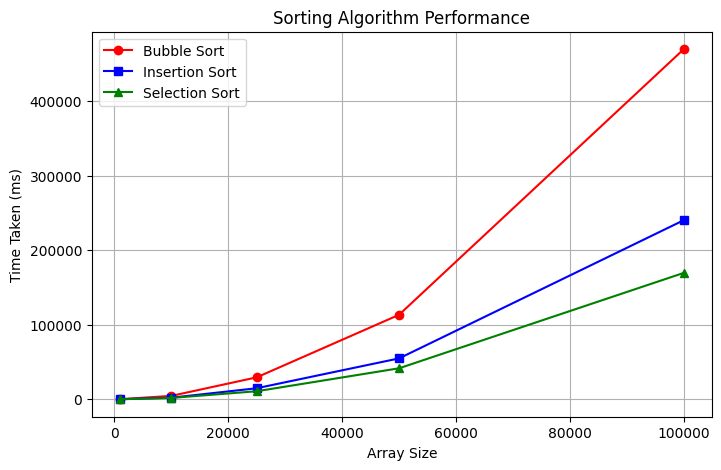

In [56]:
all_time_ms = [[t * 1000 for t in sublist] for sublist in all_time]
bubble_times = [t[0] for t in all_time_ms]
insertion_times = [t[1] for t in all_time_ms]
selection_times = [t[2] for t in all_time_ms]

plt.figure(figsize=(8, 5))
plt.plot(array_sizes, bubble_times, marker='o', color='red', label='Bubble Sort')
plt.plot(array_sizes, insertion_times, marker='s', color='blue', label='Insertion Sort')
plt.plot(array_sizes, selection_times, marker='^', color='green', label='Selection Sort')
plt.xlabel("Array Size")
plt.ylabel("Time Taken (ms)")
plt.title("Sorting Algorithm Performance")
plt.legend()
plt.grid(True)
plt.show()

## Our comment 
The graph compares the performance of three sorting algorithms — Bubble Sort, Insertion Sort, and Selection Sort — across different array sizes. As expected, Bubble Sort has the steepest curve, indicating it is the slowest and scales poorly with larger arrays. Insertion Sort performs better, especially for smaller arrays, while Selection Sort consistently outperforms Bubble Sort but is slightly slower than Insertion Sort for moderate array sizes. The plot clearly illustrates the O(n²) time complexity behavior of all three algorithms, with execution time increasing dramatically as array size grows.